In [141]:
import requests
import pandas as pd 
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import time

In [142]:
# keyword_list = input("Enter Keyword here: ")
keyword_list = ["AI"]

In [143]:
WAIT_SECONDS = 30
MAX_RETRIES = 5
retries = 0

# -------------------------
# pytrends init
# -------------------------
pytrends = TrendReq(
    hl='en-US',
    tz=360,
    timeout=(10, 25),
    requests_args={'verify': False},
)


while retries < MAX_RETRIES:

        try:
            print("Sending request...")

            pytrends.build_payload(
                [keyword_list[0]],
                timeframe='today 3-m'
            )

            realted = pytrends.related_queries()

            print("✅ Success!")
            break
        

        except Exception as e:
            retries += 1
            err = str(e)

            # -------------------------
            # 429 = rate limit
            # -------------------------
            if "429" in err:
                wait = WAIT_SECONDS * retries * 2
                print(f"⚠️ 429 Rate limit. Waiting {wait}s")
                print(f"Attempt number: {retries}")
                time.sleep(wait)

            # -------------------------
            # 500 = Google internal error
            # -------------------------
            elif "500" in err:
                wait = WAIT_SECONDS * retries
                print(f"⚠️ 500 Google error. Retry in {wait}s")
                print(f"Attempt number: {retries}")
                time.sleep(wait)

            # -------------------------
            # 400 = bad keyword combo
            # -------------------------
            elif "400" in err:
                print("⚠️ 400 bad keyword combo:", keyword_list[0])
                print(f"Attempt number: {retries}")
                break

            # -------------------------
            # anything else
            # -------------------------
            else:
                wait = WAIT_SECONDS
                print("❌ Unknown error:", e)
                print(f"Retrying in {wait}s")
                time.sleep(wait)

else:
    print(f"Attempt number: {retries}")
    print("❌ Max retries reached. Skipping:", keyword_list[0])


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Sending request...


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


✅ Success!


In [144]:
keyword_top_related = realted[keyword_list[0]]["top"]
keyword_top_related.sort_values(by="value", inplace=True, ascending=False)
keyword_related = (keyword_top_related["query"]).tolist()
keyword_list.extend(keyword_related)
print (f"Realted keywords: {keyword_top_related}")

Realted keywords:                query  value
0          gemini ai    100
1          google ai     60
2         what is ai     47
3          claude ai     33
4            ai news     28
5             ai app     26
6         chatgpt ai     22
7            open ai     18
8          ai studio     18
9            ai chat     18
10      character ai     15
11       ai detector     14
12           grok ai     11
13      microsoft ai     11
14            gpt ai     11
15           meta ai     11
16          cloud ai     10
17  google ai studio     10
18           ai mode      9
19  google gemini ai      8
20           flow ai      8
21     perplexity ai      7
22          kling ai      4
23         cursor ai      3
24     higgsfield ai      2


In [145]:
def batch_list(lst, size= 5):
    for i in range(0, len(lst), size):
        yield lst[i:i+size]

for batch in batch_list(keyword_list):
    print(batch)

['AI', 'gemini ai', 'google ai', 'what is ai', 'claude ai']
['ai news', 'ai app', 'chatgpt ai', 'open ai', 'ai studio']
['ai chat', 'character ai', 'ai detector', 'grok ai', 'microsoft ai']
['gpt ai', 'meta ai', 'cloud ai', 'google ai studio', 'ai mode']
['google gemini ai', 'flow ai', 'perplexity ai', 'kling ai', 'cursor ai']
['higgsfield ai']


In [146]:
# -------------------------
# pytrends init
# -------------------------
pytrends = TrendReq(
    hl='en-US',
    tz=360,
    timeout=(10, 25),
    requests_args={'verify': False},
)

all_data = []
retries = 0

# -------------------------
# main loop
# -------------------------
for batch in batch_list(keyword_list, 5):


    while retries < MAX_RETRIES:
        try:
            print(f"\nSending request: {batch}")

            pytrends.build_payload(
                batch,
                timeframe='today 12-m'
            )

            iot = pytrends.interest_over_time()

            if iot.empty:
                raise ValueError("Empty dataframe")

            all_data.append(iot)
            retries = 0
            print("✅ Success")
            break

        except Exception as e:
            retries += 1
            err = str(e)

            # -------------------------
            # 429 = rate limit
            # -------------------------
            if "429" in err:
                wait = WAIT_SECONDS * retries * 2
                print(f"⚠️ 429 Rate limit. Waiting {wait}s")
                time.sleep(wait)

            # -------------------------
            # 500 = Google internal error
            # -------------------------
            elif "500" in err:
                wait = WAIT_SECONDS * retries
                print(f"⚠️ 500 Google error. Retry in {wait}s")
                time.sleep(wait)

            # -------------------------
            # 400 = bad keyword combo
            # -------------------------
            elif "400" in err:
                print("⚠️ 400 Bad request. Skipping batch:", batch)
                break

            # -------------------------
            # anything else
            # -------------------------
            else:
                wait = WAIT_SECONDS
                print("❌ Unknown error:", e)
                print(f"Retrying in {wait}s")
                time.sleep(wait)

    else:
        print("❌ Max retries reached. Skipping:", batch)


# -------------------------
# combine results
# -------------------------
if all_data:
    final_df = pd.concat(all_data)
else:
    final_df = pd.DataFrame()

final_df


Sending request: ['AI', 'gemini ai', 'google ai', 'what is ai', 'claude ai']


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnin

✅ Success

Sending request: ['ai news', 'ai app', 'chatgpt ai', 'open ai', 'ai studio']


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('fu

✅ Success

Sending request: ['ai chat', 'character ai', 'ai detector', 'grok ai', 'microsoft ai']


...

✅ Success

Sending request: ['higgsfield ai']


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


✅ Success


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,AI,gemini ai,google ai,what is ai,claude ai,isPartial,ai news,ai app,chatgpt ai,open ai,...,meta ai,cloud ai,google ai studio,ai mode,google gemini ai,flow ai,perplexity ai,kling ai,cursor ai,higgsfield ai
date,,,,,,,,,,,,,,,,,,,,,
2025-04-13,46.0,2.0,1.0,1.0,0.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-20,44.0,2.0,1.0,1.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-27,44.0,1.0,1.0,1.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-04,44.0,2.0,2.0,1.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-11,45.0,2.0,2.0,1.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-15,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.0
2026-03-22,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.0
2026-03-29,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0


Database shape: (318, 26)


<Axes: xlabel='date'>

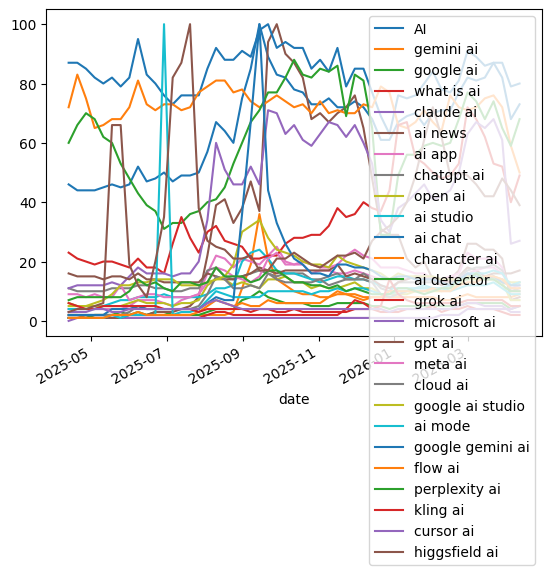

In [147]:
final_df.drop(columns=["isPartial"], inplace=True)
print(f"Database shape: {final_df.shape}")
final_df.plot()

In [148]:
raw_backup = final_df.copy()

<Axes: xlabel='date'>

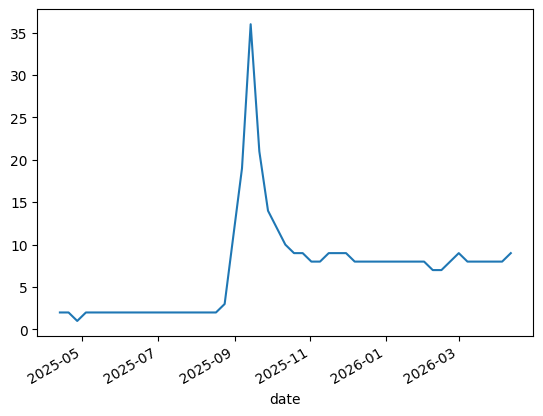

In [149]:
final_df["gemini ai"].plot()

In [170]:
df_melt = final_df.reset_index().melt(
    id_vars="date",
    var_name="keyword",
    value_name="value"
)
df = df_melt.sort_values(["keyword", "date"])
df.reset_index(inplace=True)
df.drop(columns=["index"], inplace=True)
df = df.drop_duplicates(subset=["date", "keyword"], keep="first")
df = df.sort_values(["keyword", "date"]).reset_index(drop=True)
print(df.duplicated(subset=["date", "keyword"]).sum())
df.head()

0


,date,keyword,value
0,2025-04-13,AI,46.0
1,2025-04-20,AI,44.0
2,2025-04-27,AI,44.0
3,2025-05-04,AI,44.0
4,2025-05-11,AI,45.0


In [171]:
df["keyword"].unique()

array(['AI', 'ai app', 'ai chat', 'ai detector', 'ai mode', 'ai news',
       'ai studio', 'character ai', 'chatgpt ai', 'claude ai', 'cloud ai',
       'cursor ai', 'flow ai', 'gemini ai', 'google ai',
       'google ai studio', 'google gemini ai', 'gpt ai', 'grok ai',
       'higgsfield ai', 'kling ai', 'meta ai', 'microsoft ai', 'open ai',
       'perplexity ai', 'what is ai'], dtype=object)

In [172]:
df["velocity"] = (
    df.groupby("keyword")["value"]
      .diff()
)

df["velocity_short"] = (
    df.groupby("keyword")["value"]
      .transform(lambda x: x.rolling(14).mean().diff())
)

df["velocity_medium"] = (
    df.groupby("keyword")["value"]
      .transform(lambda x: x.rolling(30).mean().diff())
)

df["velocity_long"] = (
    df.groupby("keyword")["value"]
      .transform(lambda x: x.rolling(60).mean().diff())
)

df["acceleration"] = (
    df.groupby("keyword")["velocity"]
      .transform(lambda x: x.diff()))
df.tail(10)

,date,keyword,value,velocity,velocity_short,velocity_medium,velocity_long,acceleration
1368,2026-02-08,what is ai,3.0,-2.0,0.071429,0.066667,NaN,-3.0
1369,2026-02-15,what is ai,4.0,1.0,0.142857,0.100000,NaN,3.0
1370,2026-02-22,what is ai,4.0,0.0,0.142857,0.100000,NaN,-1.0
1371,2026-03-01,what is ai,5.0,1.0,0.071429,0.100000,NaN,1.0
1372,2026-03-08,what is ai,4.0,-1.0,-0.214286,0.033333,NaN,-2.0
1373,2026-03-15,what is ai,4.0,0.0,-0.142857,0.033333,NaN,1.0
1374,2026-03-22,what is ai,4.0,0.0,0.000000,0.066667,NaN,0.0
1375,2026-03-29,what is ai,3.0,-1.0,0.000000,0.033333,NaN,-1.0
1376,2026-04-05,what is ai,2.0,-1.0,-0.071429,0.000000,NaN,0.0
1377,2026-04-12,what is ai,2.0,0.0,-0.071429,0.000000,NaN,1.0


In [173]:
from scipy.stats import median_abs_deviation
def Zscore_robust(x):
    x = x.astype(float)
    median = x.median()
    mad = median_abs_deviation(x, nan_policy="omit")
    if mad == 0:
        return x - median 
    return (x- median) / mad

df["velocity_short_zscore"] = (
    df.groupby("keyword")["velocity_short"]
    .transform(Zscore_robust)
)

df["velocity_long_zscore"] = (
    df.groupby("keyword")["velocity_long"]
    .transform(Zscore_robust)
)

df["acceleration_zscore"] = (
    df.groupby("keyword")["acceleration"]
    .transform(Zscore_robust)
)
print(df.shape)
df.head(10)

(1378, 11)


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ques

,date,keyword,value,velocity,velocity_short,velocity_medium,velocity_long,acceleration,velocity_short_zscore,velocity_long_zscore,acceleration_zscore
0,2025-04-13,AI,46.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-20,AI,44.0,-2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-27,AI,44.0,0.0,NaN,NaN,NaN,2.0,NaN,NaN,0.25
3,2025-05-04,AI,44.0,0.0,NaN,NaN,NaN,0.0,NaN,NaN,-0.25
4,2025-05-11,AI,45.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,0.00
5,2025-05-18,AI,46.0,1.0,NaN,NaN,NaN,0.0,NaN,NaN,-0.25
6,2025-05-25,AI,45.0,-1.0,NaN,NaN,NaN,-2.0,NaN,NaN,-0.75
7,2025-06-01,AI,46.0,1.0,NaN,NaN,NaN,2.0,NaN,NaN,0.25
8,2025-06-08,AI,52.0,6.0,NaN,NaN,NaN,5.0,NaN,NaN,1.00
9,2025-06-15,AI,47.0,-5.0,NaN,NaN,NaN,-11.0,NaN,NaN,-3.00


In [174]:
from scipy.stats import norm

def classify_regime(row):
    sz = row['velocity_short_zscore']
    lz = row['velocity_long_zscore']
    az = row['acceleration_zscore']

    if pd.isna(sz) or pd.isna(lz):
        return 'Insufficient Data'
    
    # Crossover signal: short momentum vs long momentum
    crossover = sz - lz  

    if sz > 2 and crossover > 0:
        return 'Spike'
    elif sz > 1 and crossover > 0:
        return 'Building'
    elif sz < -1.5 or (crossover < -1 and lz > 0):
        return 'Collapsing'
    else:
        return 'Quiet'

df['regime'] = df.apply(classify_regime, axis=1)

In [175]:
df.groupby("keyword")["velocity"].sum()

keyword
AI                  27.0
ai app               0.0
ai chat              0.0
ai detector          0.0
ai mode              0.0
ai news              0.0
ai studio            0.0
character ai         0.0
chatgpt ai           0.0
claude ai            5.0
cloud ai             0.0
cursor ai            0.0
flow ai              0.0
gemini ai            7.0
google ai            4.0
google ai studio     0.0
google gemini ai     0.0
gpt ai               0.0
grok ai              0.0
higgsfield ai        0.0
kling ai             0.0
meta ai              0.0
microsoft ai         0.0
open ai              0.0
perplexity ai        0.0
what is ai           1.0
Name: velocity, dtype: float64

In [176]:
verdict_map = {
    'Spike':               ('🟢 ACT NOW',   'Strong real momentum. Publish immediately.'),
    'Building':            ('🟡 WATCH',     'Momentum building. Prepare content now.'),
    'Quiet':               ('⚪ WAIT',      'No real signal. Hold content.'),
    'Collapsing':          ('🔴 HOLD OFF',  'Trend reversing. Poor time to publish.'),
    'Insufficient Data':   ('⏳ NO SIGNAL', 'Not enough data yet.')
}

def print_verdict(df, keyword):
    kdf = df[df['keyword'] == keyword].copy()
    latest = kdf.iloc[-1]
    
    regime = latest['regime']
    signal, explanation = verdict_map[regime]
    
    # p-value from short z-score
    sz = latest['velocity_short_zscore']
    p = round(1 - norm.cdf(sz), 4) if not pd.isna(sz) else None
    
    print("=" * 45)
    print(f"  KEYWORD     : {keyword}")
    print(f"  DATE        : {latest['date']}")
    print(f"  TREND SCORE : {latest['value']}")
    print(f"  SHORT Z     : {round(sz, 2) if not pd.isna(sz) else 'N/A'}")
    print(f"  LONG Z      : {round(latest['velocity_long_zscore'], 2) if not pd.isna(latest['velocity_long_zscore']) else 'N/A'}")
    print(f"  P-VALUE     : {p if p else 'N/A'}")
    print(f"  REGIME      : {regime}")
    print(f"  VERDICT     : {signal}")
    print(f"  REASON      : {explanation}")
    print("=" * 45)

In [177]:
from scipy.stats import norm
import pandas as pd

def build_summary(df):
    latest = (
        df.sort_values("date")
          .groupby("keyword")
          .tail(1)
          .copy()
    )

    latest["p_value"] = latest["velocity_short_zscore"].apply(
        lambda x: 1 - norm.cdf(x) if pd.notna(x) else None
    )

    latest["verdict"] = latest["regime"].map(lambda r: verdict_map[r][0])
    latest["reason"] = latest["regime"].map(lambda r: verdict_map[r][1])

    summary = latest[[
        "keyword",
        "date",
        "value",
        "velocity_short_zscore",
        "velocity_long_zscore",
        "p_value",
        "regime",
        "verdict"
    ]]

    return summary.sort_values("velocity_short_zscore", ascending=False)

summary = build_summary(df)
summary.reset_index()

,index,keyword,date,value,velocity_short_zscore,velocity_long_zscore,p_value,regime,verdict
0,741,gemini ai,2026-04-12,9.0,0.333333,NaN,0.369441,Insufficient Data,⏳ NO SIGNAL
1,529,claude ai,2026-04-12,5.0,0.285714,NaN,0.387548,Insufficient Data,⏳ NO SIGNAL
2,52,AI,2026-04-12,73.0,-0.307692,NaN,0.620842,Insufficient Data,⏳ NO SIGNAL
3,794,google ai,2026-04-12,5.0,-1.000000,NaN,0.841345,Insufficient Data,⏳ NO SIGNAL
4,1377,what is ai,2026-04-12,2.0,-2.000000,NaN,0.977250,Insufficient Data,⏳ NO SIGNAL
5,688,flow ai,2026-04-12,NaN,NaN,NaN,NaN,Insufficient Data,⏳ NO SIGNAL
6,1271,open ai,2026-04-12,NaN,NaN,NaN,NaN,Insufficient Data,⏳ NO SIGNAL
7,105,ai app,2026-04-12,NaN,NaN,NaN,NaN,Insufficient Data,⏳ NO SIGNAL
8,158,ai chat,2026-04-12,NaN,NaN,NaN,NaN,Insufficient Data,⏳ NO SIGNAL
9,211,ai detector,2026-04-12,NaN,NaN,NaN,NaN,Insufficient Data,⏳ NO SIGNAL


In [178]:
summary

,keyword,date,value,velocity_short_zscore,velocity_long_zscore,p_value,regime,verdict
741,gemini ai,2026-04-12,9.0,0.333333,NaN,0.369441,Insufficient Data,⏳ NO SIGNAL
529,claude ai,2026-04-12,5.0,0.285714,NaN,0.387548,Insufficient Data,⏳ NO SIGNAL
52,AI,2026-04-12,73.0,-0.307692,NaN,0.620842,Insufficient Data,⏳ NO SIGNAL
794,google ai,2026-04-12,5.0,-1.000000,NaN,0.841345,Insufficient Data,⏳ NO SIGNAL
1377,what is ai,2026-04-12,2.0,-2.000000,NaN,0.977250,Insufficient Data,⏳ NO SIGNAL
688,flow ai,2026-04-12,NaN,NaN,NaN,NaN,Insufficient Data,⏳ NO SIGNAL
1271,open ai,2026-04-12,NaN,NaN,NaN,NaN,Insufficient Data,⏳ NO SIGNAL
105,ai app,2026-04-12,NaN,NaN,NaN,NaN,Insufficient Data,⏳ NO SIGNAL
158,ai chat,2026-04-12,NaN,NaN,NaN,NaN,Insufficient Data,⏳ NO SIGNAL
211,ai detector,2026-04-12,NaN,NaN,NaN,NaN,Insufficient Data,⏳ NO SIGNAL


In [180]:
summary.sort_values(by="value", ascending=False)
final_summary = summary.dropna(subset="value")
# final_summary.drop(columns="index").reset_index()
# raw_backup.duplicated(subset=["date", "keyword"])
final_summary


,keyword,date,value,velocity_short_zscore,velocity_long_zscore,p_value,regime,verdict
741,gemini ai,2026-04-12,9.0,0.333333,NaN,0.369441,Insufficient Data,⏳ NO SIGNAL
529,claude ai,2026-04-12,5.0,0.285714,NaN,0.387548,Insufficient Data,⏳ NO SIGNAL
52,AI,2026-04-12,73.0,-0.307692,NaN,0.620842,Insufficient Data,⏳ NO SIGNAL
794,google ai,2026-04-12,5.0,-1.000000,NaN,0.841345,Insufficient Data,⏳ NO SIGNAL
1377,what is ai,2026-04-12,2.0,-2.000000,NaN,0.977250,Insufficient Data,⏳ NO SIGNAL


In [182]:
top_keywords = final_summary["keyword"]
(top_keywords.sort_values(ascending=False))
top_keywords

741      gemini ai
529      claude ai
52              AI
794      google ai
1377    what is ai
Name: keyword, dtype: object

In [183]:
for keys in top_keywords:
    print_verdict(df, keys)

  KEYWORD     : gemini ai
  DATE        : 2026-04-12 00:00:00
  TREND SCORE : 9.0
  SHORT Z     : 0.33
  LONG Z      : N/A
  P-VALUE     : 0.3694
  REGIME      : Insufficient Data
  VERDICT     : ⏳ NO SIGNAL
  REASON      : Not enough data yet.
  KEYWORD     : claude ai
  DATE        : 2026-04-12 00:00:00
  TREND SCORE : 5.0
  SHORT Z     : 0.29
  LONG Z      : N/A
  P-VALUE     : 0.3875
  REGIME      : Insufficient Data
  VERDICT     : ⏳ NO SIGNAL
  REASON      : Not enough data yet.
  KEYWORD     : AI
  DATE        : 2026-04-12 00:00:00
  TREND SCORE : 73.0
  SHORT Z     : -0.31
  LONG Z      : N/A
  P-VALUE     : 0.6208
  REGIME      : Insufficient Data
  VERDICT     : ⏳ NO SIGNAL
  REASON      : Not enough data yet.
  KEYWORD     : google ai
  DATE        : 2026-04-12 00:00:00
  TREND SCORE : 5.0
  SHORT Z     : -1.0
  LONG Z      : N/A
  P-VALUE     : 0.8413
  REGIME      : Insufficient Data
  VERDICT     : ⏳ NO SIGNAL
  REASON      : Not enough data yet.
  KEYWORD     : what is a

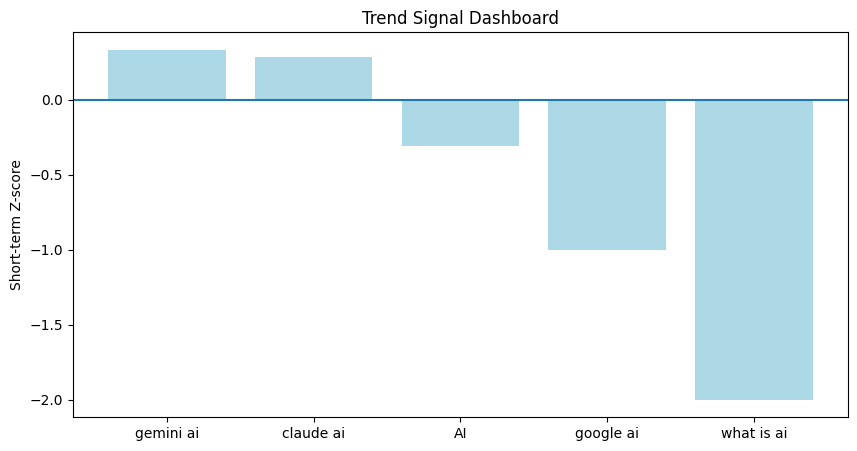

In [184]:
colors = summary["regime"].map({
    "Spike": "green",
    "Building": "gold",
    "Quiet": "gray",
    "Collapsing": "red",
    "Insufficient Data": "lightblue"
})

plt.figure(figsize=(10,5))
plt.bar(summary["keyword"], summary["velocity_short_zscore"], color=colors)
plt.axhline(0)
plt.title("Trend Signal Dashboard")
plt.ylabel("Short-term Z-score")
plt.show()

In [185]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

regime_colors = {
    'Spike':             '#c8f7c5',
    'Building':          '#fef9c3',
    'Quiet':             '#f0f0f0',
    'Collapsing':        '#fdd',
    'Insufficient Data': '#ffffff'
}

def plot_keyword(df, keyword):
    kdf = df[df['keyword'] == keyword].copy()
    kdf['date'] = pd.to_datetime(kdf['date'])
    kdf = kdf.sort_values('date')

    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(14, 8), 
        sharex=True,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    # ── Top panel: trend score + regime background ──
    for i in range(len(kdf) - 1):
        regime = kdf['regime'].iloc[i]
        ax1.axvspan(
            kdf['date'].iloc[i],
            kdf['date'].iloc[i + 1],
            color=regime_colors[regime],
            alpha=0.6
        )

    ax1.plot(kdf['date'], kdf['value'], 
             color='#1a1a2e', linewidth=2.5, label='Trend Score', zorder=3)
    ax1.set_ylabel('Google Trends Score (0–100)', fontsize=11)
    ax1.set_title(f'Campaign Signal Dashboard — "{keyword}"', 
                  fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylim(0, 110)
    ax1.grid(axis='y', alpha=0.3)

    # ── Bottom panel: z-scores ──
    ax2.plot(kdf['date'], kdf['velocity_short_zscore'],
             color='#e67e22', linewidth=2, label='Short Z-Score (3d)', zorder=3)
    ax2.plot(kdf['date'], kdf['velocity_long_zscore'],
             color='#2980b9', linewidth=2, label='Long Z-Score (7d)', zorder=3)
    
    # significance threshold lines
    ax2.axhline(y=2,  color='green', linestyle='--', alpha=0.7, linewidth=1, label='Significant (z=2)')
    ax2.axhline(y=-1.5, color='red', linestyle='--', alpha=0.7, linewidth=1, label='Collapse (z=-1.5)')
    ax2.axhline(y=0,  color='gray', linestyle='-',  alpha=0.3, linewidth=1)
    
    ax2.set_ylabel('Z-Score', fontsize=11)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.grid(axis='y', alpha=0.3)
    ax2.legend(loc='upper left', fontsize=9)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)

    # ── Regime legend ──
    patches = [
        mpatches.Patch(color='#c8f7c5', label='🟢 Spike — Act Now'),
        mpatches.Patch(color='#fef9c3', label='🟡 Building — Watch'),
        mpatches.Patch(color='#f0f0f0', label='⚪ Quiet — Wait'),
        mpatches.Patch(color='#fdd',    label='🔴 Collapsing — Hold')
    ]
    ax1.legend(handles=patches, loc='upper left', fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyp

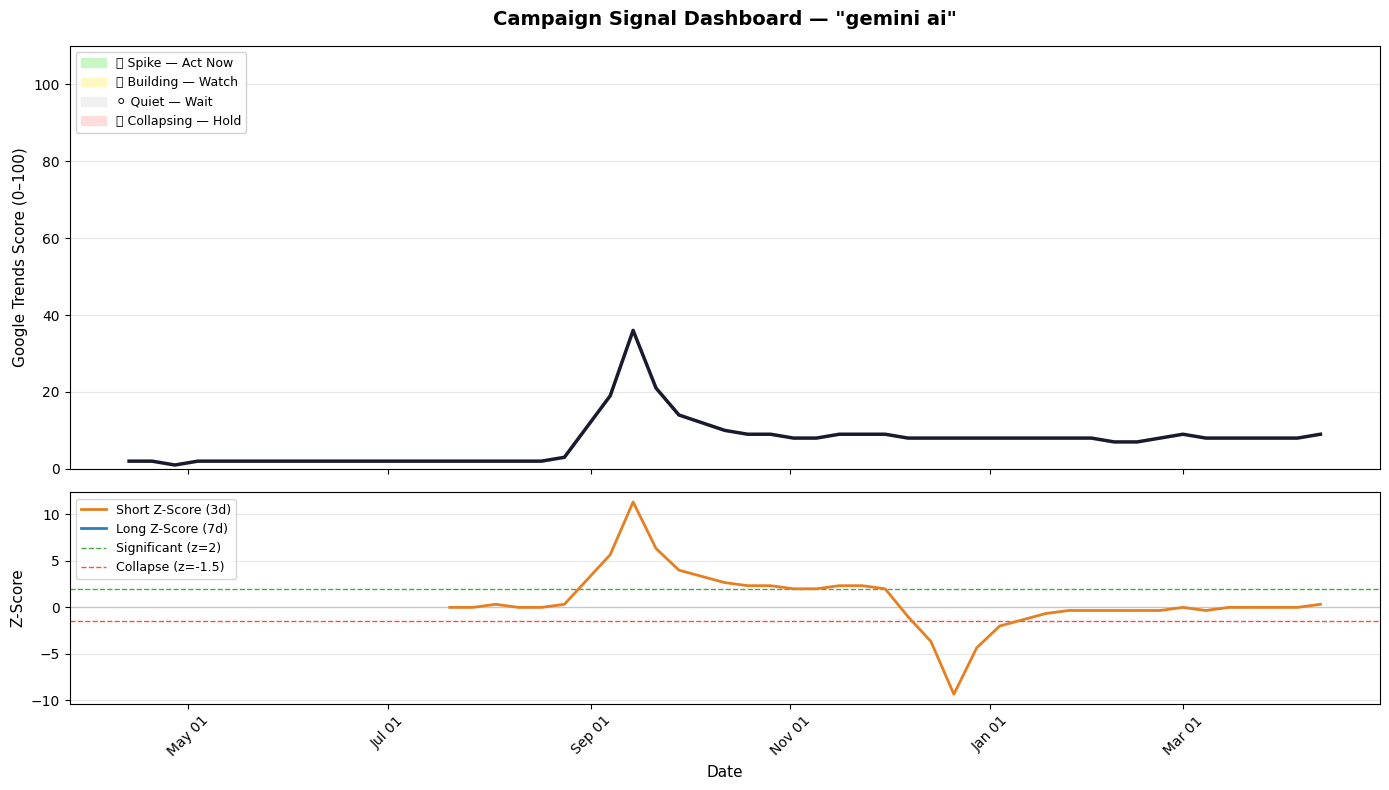

/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyp

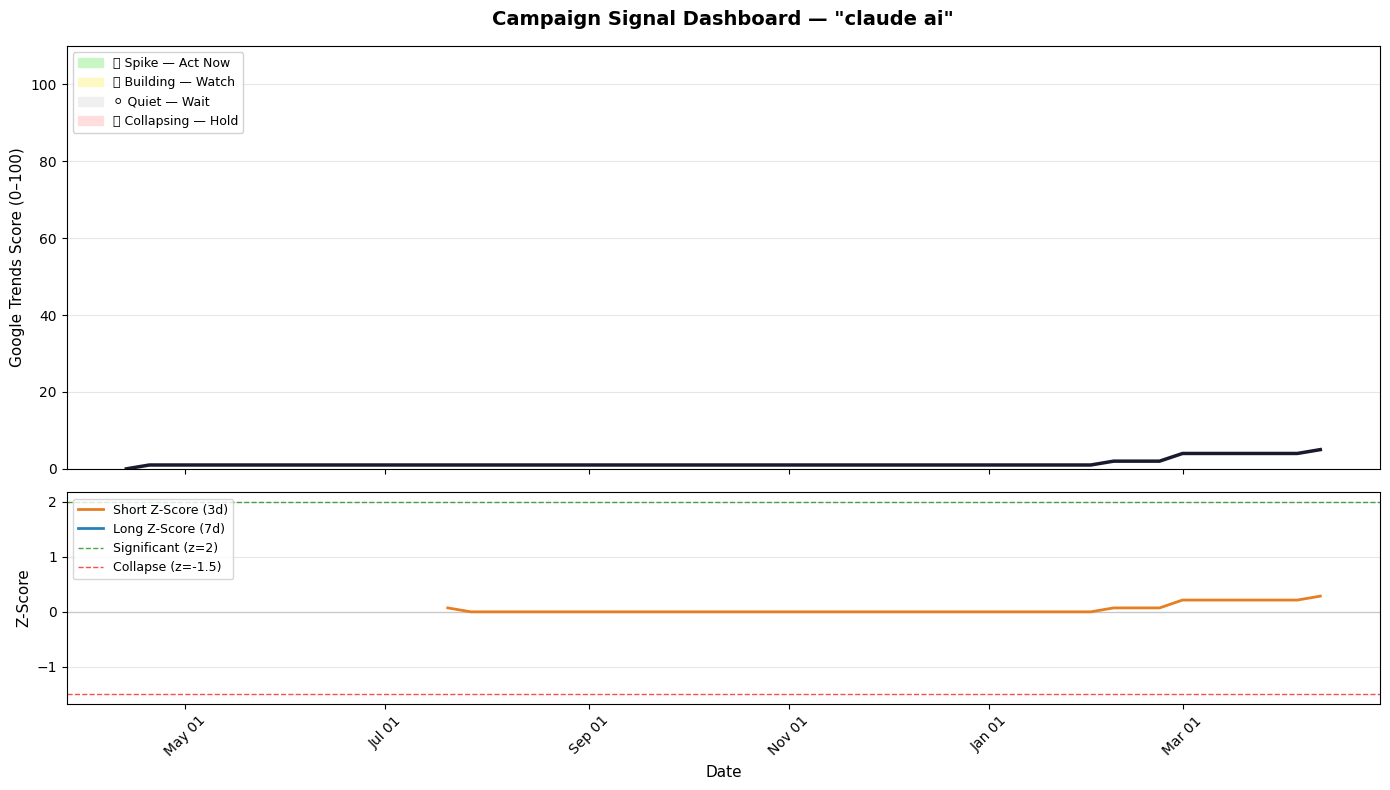

/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyp

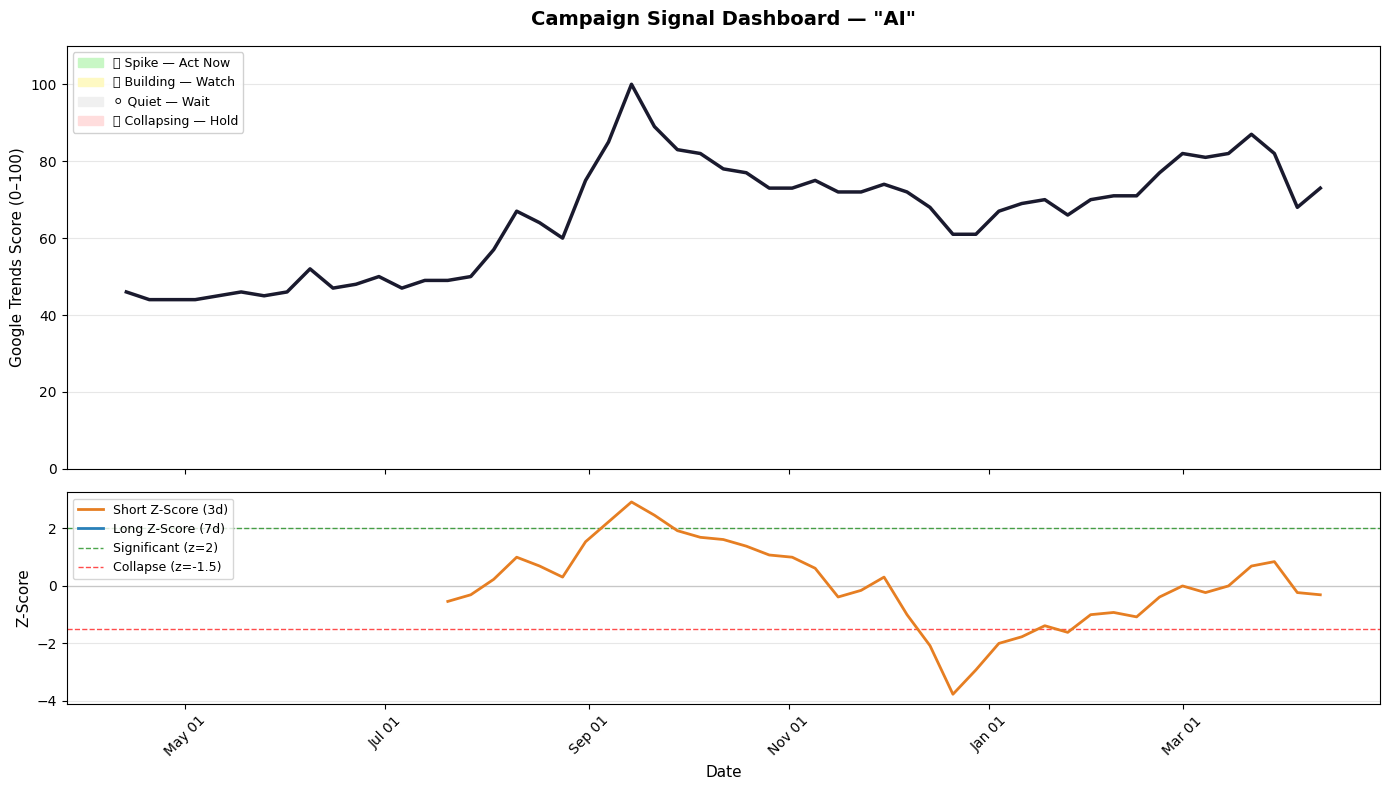

/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyp

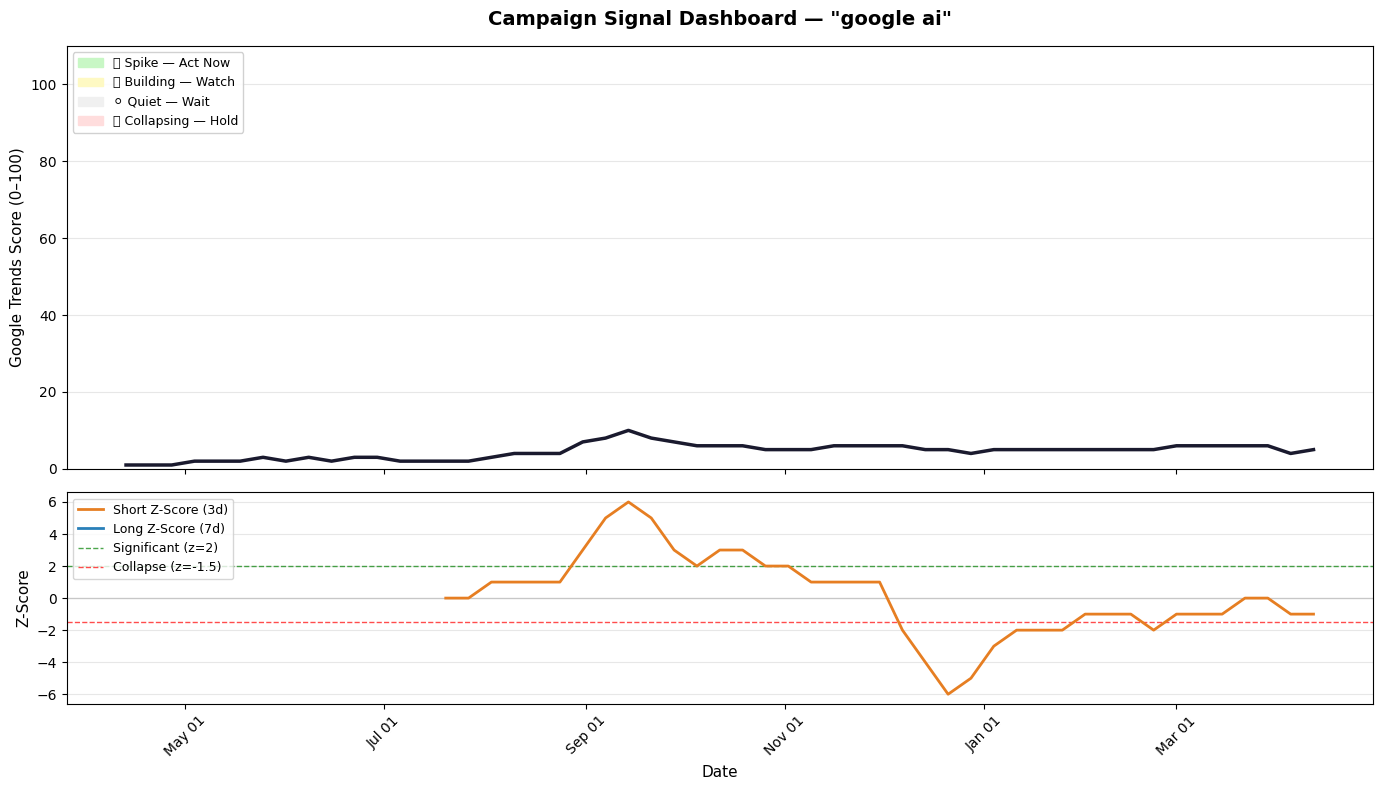

/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyp

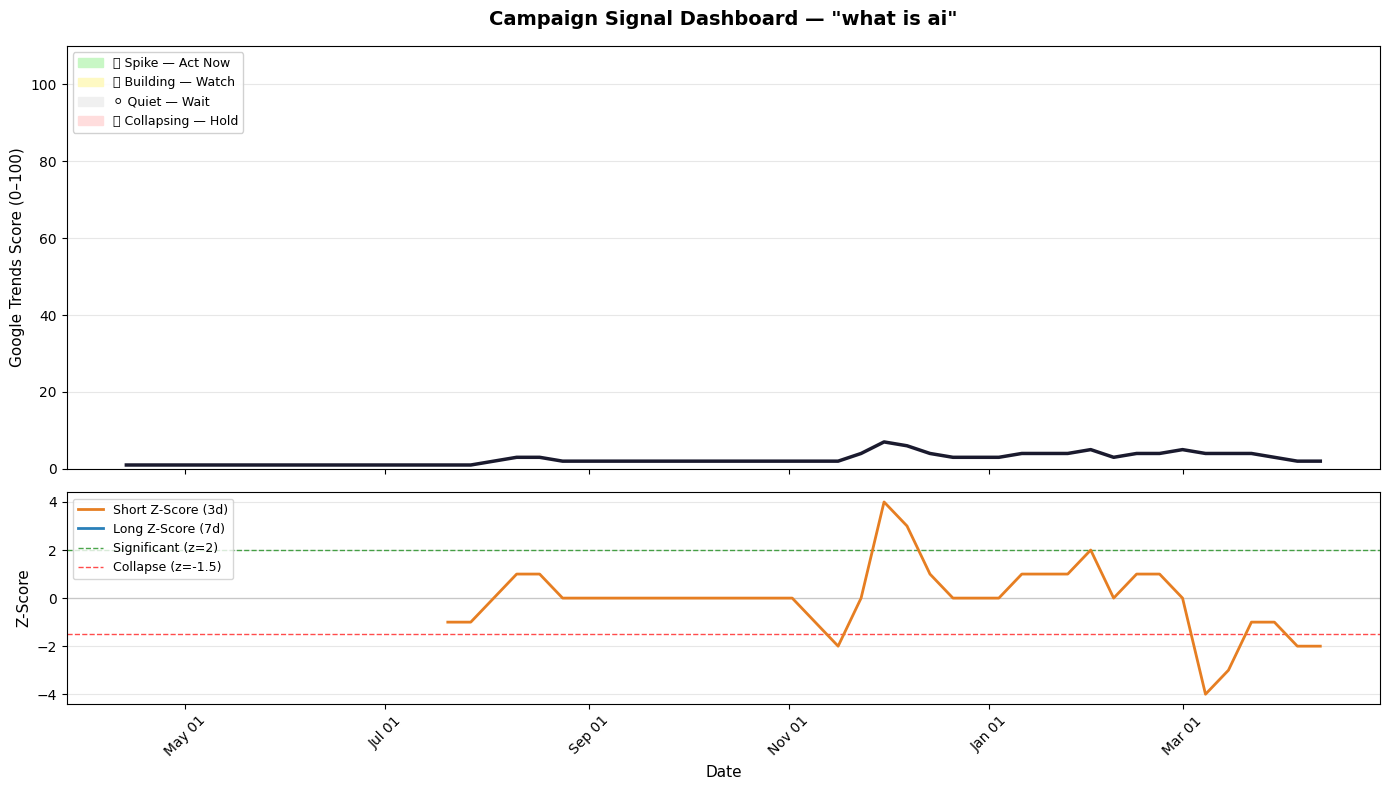

In [190]:
for k in final_summary.keyword:
    plot_keyword(df, k)

/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25889/606582397.py:70: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyp

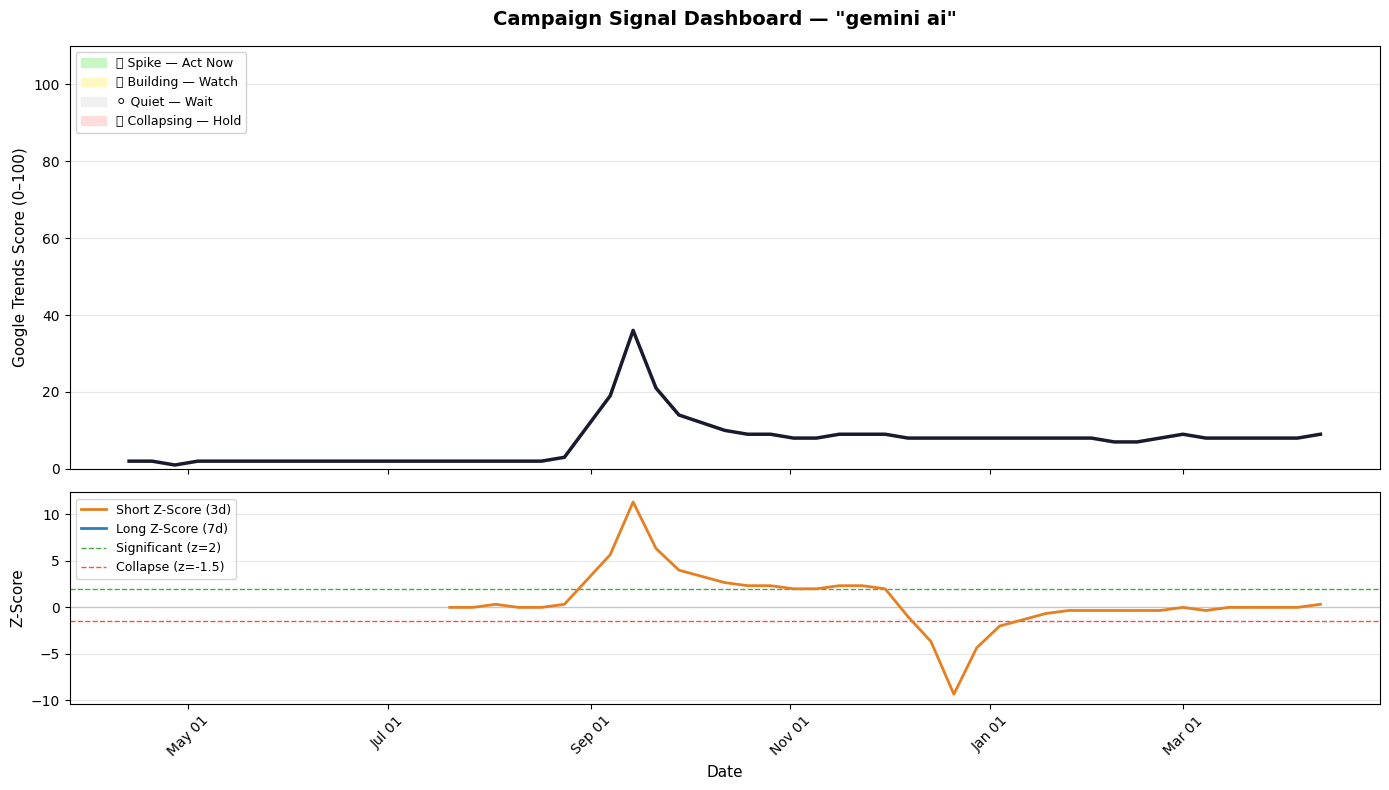

In [187]:
plot_keyword(df, "gemini ai")

In [ ]:
plot_keyword(df, related_keywords[2])

NameError: name 'related_keywords' is not defined

In [ ]:
(top_keywords.sort_values(ascending=False))

14195          what is ai
13644              use ai
13098       perplexity ai
12553             open ai
12011        microsoft ai
11460             meta ai
10914            kling ai
10368             grok ai
9822               gpt ai
9276     google gemini ai
8733     google ai studio
8184            google ai
7638            gemini ai
7096              flow ai
6546            cursor ai
6000             cloud ai
5455            claude ai
4913           chatgpt ai
4362         character ai
3816            anthropic
3270            ai studio
2724              ai news
2179              ai mode
1637          ai detector
1086              ai chat
540                    AI
Name: keyword, dtype: object